# Andmete eksploratiivne analüüs

In [753]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

## Graafikute seadistused

In [1011]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style = 'whitegrid', rc = custom_params)

def set_raport_style():
    sns.set_theme(style="whitegrid")

    plt.rcParams.update({
        # font
        #"font.family": "sans-serif",
        #"font.size": 10,
        'axes.titlesize': 13,
        'axes.labelsize': 10,

        # telgede stiil
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': False,

        # grid
        #"axes.grid": True,
        'grid.linestyle': '--',
        'grid.alpha': 0.4,

        # legend
        'legend.frameon': False,

        # figure
        #"figure.dpi": 120
    })

set_raport_style()

PALETTE = ["#3B5BA5", "#55A868", "#C44E52", "#8172B3", "#CCB974"]
PRIMARY_COLOR = "#3B5BA5"

## Andmete import

In [163]:
# Impordi andmed puhastamise käigus loodud CVS-st
data = pd.read_csv('data/cleaned_data.csv')
data

,Vastaja_ID,K1_aeg,K2_kontroll,K3_vanus,K4_sugu,K5_elukoht,K6_keel,K7_sorteerimiskaitumine,K8_teadmiste_hinnang,K9_probleemi_tosidus,...,K32_teabe_allikad_10,K32_teabe_allikad_muu_tekst,K33_julgustavad_tegurid_1,K33_julgustavad_tegurid_2,K33_julgustavad_tegurid_3,K33_julgustavad_tegurid_4,K33_julgustavad_tegurid_5,K33_julgustavad_tegurid_6,K33_julgustavad_tegurid_7,K33_julgustavad_tegurid_muu_tekst
0,1,2025-03-10 08:01:13,1,2,2,1,1,2,5,5,...,0,NaN,1,1,1,1,0,1,0,NaN
1,2,2025-03-10 16:55:18,1,2,2,9,1,3,3,3,...,0,NaN,1,1,0,0,0,0,0,NaN
2,3,2025-03-17 21:06:37,1,4,2,1,1,2,4,5,...,0,NaN,1,1,0,1,0,0,0,NaN
3,4,2025-03-17 20:00:21,1,4,2,16,1,3,2,5,...,0,NaN,1,0,0,0,0,0,0,NaN
4,5,2025-03-20 21:15:13,1,2,2,12,1,3,4,5,...,0,NaN,1,1,1,1,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,674,2025-03-28 16:34:49,1,4,2,9,1,2,2,5,...,0,NaN,1,1,0,0,1,0,0,NaN
664,675,2025-04-13 09:46:43,1,2,2,1,1,4,4,5,...,0,NaN,1,1,1,0,0,0,0,NaN
665,676,2025-04-15 13:31:30,1,4,2,1,1,3,3,5,...,0,NaN,1,1,1,0,1,0,0,NaN
666,677,2025-03-11 19:48:03,1,3,2,1,1,3,3,4,...,0,NaN,1,0,1,0,0,0,0,NaN


In [705]:
koodid = pd.read_csv('data/vastuste_koodid.csv')
koodid

,kysimus,kood,vastus,vastus_lyhike
0,K2_kontroll,1,Jah,Jah
1,K2_kontroll,2,Ei,Ei
2,K3_vanus,1,Alaealine (17 või noorem),<17
3,K3_vanus,2,18-29,18-29
4,K3_vanus,3,30-49,30-49
...,...,...,...,...
168,K43_roivaste_tellimine_proovimiseks,1,Ei ole seda kordagi teinud,NaN
169,K43_roivaste_tellimine_proovimiseks,2,2 - puudu,NaN
170,K43_roivaste_tellimine_proovimiseks,3,3 - puudu,NaN
171,K43_roivaste_tellimine_proovimiseks,4,4 - puudu,NaN


## Abifunktsioonid

In [706]:
def leia_sildi_mapping(df_labels, tunnus):
     return (
        df_labels[df_labels['kysimus'] == tunnus]
        .set_index('kood')['vastus_lyhike']
        .to_dict()
    )

In [1216]:
def sagedustabel(df_data, df_koodid, tunnus, use_full_codebook=True):
    
    # --- counts from data ---
    counts = df_data[tunnus].value_counts()

    if use_full_codebook:
        # use full list of possible answers
        df_map = df_koodid[df_koodid['kysimus'] == tunnus].copy()

        # ensure all codes appear
        df_map['vastuste_arv'] = df_map['kood'].map(counts).fillna(0).astype(int)

    else:
        # use only observed values (partial mode)
        df_map = counts.reset_index()
        df_map.columns = ['kood', 'vastuste_arv']

        # optionally merge labels if available
        labels = df_koodid[df_koodid['kysimus'] == tunnus][['kood', 'vastus_lyhike']]
        df_map = df_map.merge(labels, on='kood', how='left')

    # --- percentages ---
    total = df_map['vastuste_arv'].sum()
    df_map['protsent'] = (df_map['vastuste_arv'] / total * 100).round(1) if total > 0 else 0
    df_map['protsent_str'] = df_map['protsent'].map(lambda x: f'{x:.1f} %')

    return df_map[['kood', 'vastus_lyhike', 'vastuste_arv', 'protsent', 'protsent_str']]

In [710]:
# Leia tunnuse väärtuste esinemise sagedused ja esita need tabelina
def sagedustabel(df_data, df_koodid, tunnus):
    
    # --- filter mapping for this question ---
    df_map = df_koodid[df_koodid['kysimus'] == tunnus].copy()
    df_map = df_map.sort_values('kood')  # ensures correct order
    
    # --- counts from data ---
    counts = df_data[tunnus].value_counts()
    
    # --- map counts onto full list of possible answers ---
    df_map['vastuste_arv'] = df_map['kood'].map(counts).fillna(0).astype(int)
    
    # --- percentages ---
    total = df_map['vastuste_arv'].sum()
    df_map['protsent'] = (df_map['vastuste_arv'] / total * 100).round(1)
    df_map['protsent_str'] = df_map['protsent'].map(lambda x: f'{x:.1f} %')
    
    # --- final table ---
    tulemus = df_map[['vastus_lyhike', 'vastuste_arv', 'protsent', 'protsent_str']]

    return tulemus

In [242]:
# Leia tunnuse mood ehk kõige sagedamini esinev väärtus
def mood(df, veerg):
    jaotus = duckdb.sql(f'''
        SELECT
            t1.{veerg} as kood
            ,t2.vastus as vastus
        FROM df t1
        LEFT JOIN koodid t2 on t1.{veerg} = t2.kood
            AND t2.kysimus = '{veerg}'
        ORDER BY t1.K3_vanus
        ''').df()
    return jaotus.mode()

In [1217]:
# Loo vertikaalne tulpdiagramm
def loo_tulpdiagramm(df, title, percent=True, sort=False):
    
    # Vajadusel sorteeri andmestik
    if sort:
        df = df.sort_values("protsent", ascending=False)
    
    print('Vastuste jaotus:')
    print(df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(7, 5))

    # Loo diagramm
    sns.barplot(
        data=df,
        x='vastus_lyhike',
        y='protsent' if percent else "vastuste_arv", # kasutaja kas suhtarve või absoluutseid väärtuseid
        color=PRIMARY_COLOR,
        ax=ax
    )
    
    # Lisa pealkiri
    ax.set_title(title, weight='bold', loc='left', pad=15)
    
    # Eemalda telgede nimed
    ax.set(xlabel=None, ylabel=None)

    # Kui diagrammil kuvatud suhtarvud, siis muuda y-telg protsentideks
    if percent:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        # Seadista graafiku max
        ax.set_ylim(0, df["protsent"].max() * 1.15)
        #ax.set_ylim(0, max(100, df["protsent"].max() * 1.15))
    
    # Kuva minimalistlik grid
    ax.grid(axis="x", visible=False)
 
    # Lisa diagrammile tekstilised annotatsioonid
    for idx, row in enumerate(df.itertuples()):
        label = f"{row.vastuste_arv} ({row.protsent:.1f}%)"
        
        ax.text(
            idx,
            row.protsent + 1,
            label,
            horizontalalignment='center',
            verticalalignment='bottom',
            fontsize=10
        )
    
    plt.tight_layout()
    
    return fig, ax

In [1057]:
# Loo horisontaalne tulpdiagramm
def loo_hor_tulpdiagramm(df, title, percent=True, sort=False):
    
    # Vajadusel sorteeri andmestik
    if sort:
        df = df.sort_values("protsent", ascending=False)
    
    print('Vastuste jaotus:')
    print(df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(7, 5))

    # Loo diagramm
    sns.barplot(
        data=df,
        x='protsent' if percent else "vastuste_arv", # kasutaja kas suhtarve või absoluutseid väärtuseid
        y='vastus_lyhike',
        color=PRIMARY_COLOR,
        ax=ax
    )
    
    # Lisa pealkiri
    ax.set_title(title, weight='bold', loc='left', pad=15)
    
    # Eemalda telgede nimed
    ax.set(xlabel=None, ylabel=None)

    # Kui diagrammil kuvatud suhtarvud, siis muuda x-telg protsentideks
    if percent:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        # Seadista graafiku max
        ax.set_xlim(0, df["protsent"].max() * 1.15)
    
    # Kuva minimalistlik grid
    ax.grid(axis="y", visible=False)
 
    # Lisa diagrammile tekstilised annotatsioonid
    for idx, row in enumerate(df.itertuples()):
        label = f"{row.vastuste_arv} ({row.protsent:.1f}%)"
        
        ax.text(
            row.protsent + 0.5,
            idx,
            label,
            horizontalalignment='left',
            verticalalignment='center',
            fontsize=10
        )
    
    plt.tight_layout()
    
    return fig, ax

In [1218]:
def loo_stacked_tulpdiagramm(df, title, normalize=True):
    if normalize:
        # Teisenda absoluutarvud protsentideks
        df_plot = df.div(df.sum(axis=1), axis=0)
    else:
        df_plot = df.copy()
    
    print(f'\nVastuste arv: {df.sum().sum()}')
    print(f'Vastuste arv tunnuste kaupa:')
    print(df.sum(axis=1))

    # Loo stacked tulpdiagramm
    fig, ax = plt.subplots(figsize=(7, 5))
    
    df_plot.plot(
        kind="bar",
        stacked=True,
        color=PALETTE,
        ax=ax,
        width=0.8
    )

    ax.set_title(title, weight='bold', loc='left', pad=15)
    ax.set(xlabel=None, ylabel=None)
    #ax.set_xlabel('Vanusegrupp', fontsize=13, fontweight='bold')
    #ax.set_ylabel('Protsent (%)', fontsize=13, fontweight='bold')

    # Kui diagrammil kuvatud suhtarvud, siis muuda y-telg protsentideks
    if normalize:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_ylim(0, 1)
    
    # x-telg
    ax.set_xticklabels(df.index, rotation=0, ha='center')

    # Lisa segmentidele neile vastavad protsendid sildina
    for container in ax.containers:
        # Kuva silte ainult juhul kui >5
        labels = [f'{v*100:.1f}%' if v*100 > 5 else '' for v in container.datavalues]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9
        )

    # Legendi stiil
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        frameon=False
    )

    # Lisa diagrammile x-telje alla vastuste arvudele vastavad sildid
    for i, (grupp, count) in enumerate(df.sum(axis=1).items()):
        ax.text(
            i,
            -0.12,
            f'n={count}',
            ha='center',
            #va='top', 
            fontsize=9,
            style='italic',
            color='gray'
        )

    plt.tight_layout()
    #plt.savefig('/mnt/user-data/outputs/stacked_bar_final.png', dpi=300, bbox_inches='tight', facecolor='white')

    return fig, ax

In [1171]:
def loo_hor_stacked_tulpdiagramm(df, title, normalize=True, sort=True):
    
    if normalize:
        # Teisenda absoluutarvud protsentideks
        df_plot = df.div(df.sum(axis=1), axis=0)
    else:
        df_plot = df.copy()
    
    # Vajadusel sorteeri andmestik
    if sort:
        df = df.loc[df.sum(axis=1).sort_values(ascending=True).index]
    
    print(f'\nVastuste arv: {df.sum().sum()}')
    print(f'Vastuste arv tunnuste kaupa:')
    print(df.sum(axis=1))

    # Loo stacked tulpdiagramm
    fig, ax = plt.subplots(figsize=(7, 6))
    
    df_plot.plot(
        kind="barh",
        stacked=True,
        color=PALETTE,
        ax=ax
    )

    #ax.margins(y=0.1)

    ax.set_title(title, weight='bold', loc='left', pad=15)
    ax.set(xlabel=None, ylabel=None)

    # Kui diagrammil kuvatud suhtarvud, siis muuda x-telg protsentideks
    if normalize:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_xlim(0, 1)

    # y-telg
    ax.set_yticklabels(df.index)
    if not sort:
        ax.invert_yaxis()

    # Lisa segmentidele neile vastavad protsendid sildina
    for container in ax.containers:
        labels = [
            f'{v*100:.1f}%' if (normalize and v*100 > 5)
            else (f'{int(v)}' if not normalize and v > 0 else '')
            for v in container.datavalues
        ]
        
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=8
        )

    # Legendi stiil
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        frameon=False
    )

    # Lisa absoluutarvude sildid vasakule
    totals = df.sum(axis=1)
    
    # Lisa diagrammile y-telje juurde vastuste arvudele vastavad sildid
    for i, (grupp, count) in enumerate(totals.items()):
        ax.text(
            -0.03,
            i-0.5,
            f'(n={count})',
            transform=ax.get_yaxis_transform(),
            ha='right',
            va='center',
            fontsize=8,
            style='italic',
            color='gray'
        )

    # --- clean grid ---
    #ax.grid(axis='x', linestyle='--', alpha=0.4)
    #ax.grid(axis='y', visible=False)

    plt.tight_layout()

    return fig, ax

## Demograafilised näitajad

- Vanus
- Sugu
- Elukoht
- Keel

Vastanute jaotus
 kood vastus_lyhike  vastuste_arv  protsent protsent_str
    1           <17            57       8.5        8.5 %
    2         18-29           124      18.6       18.6 %
    3         30-49           370      55.4       55.4 %
    4         50-64           104      15.6       15.6 %
    5           65+            13       1.9        1.9 %


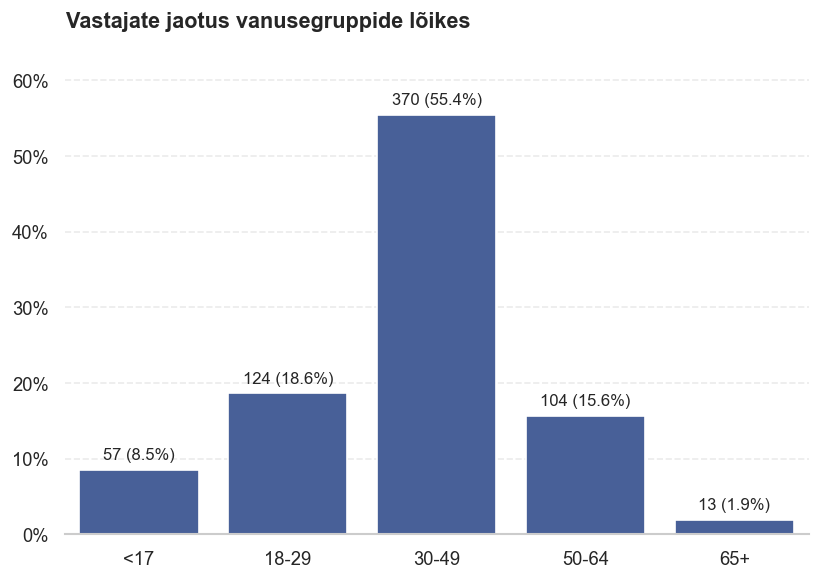

In [1211]:
# Leia vastajate arv vanusegrupiti
vanus_sagedus = sagedustabel(data, koodid, 'K3_vanus')

# Vanuse jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    vanus_sagedus,
    "Vastajate jaotus vanusegruppide lõikes"
)

plt.show()

Vastanute jaotus
 kood vastus_lyhike  vastuste_arv  protsent protsent_str
    2         Naine           591      88.5       88.5 %
    1          Mees            71      10.6       10.6 %
    3  Määratlemata             6       0.9        0.9 %


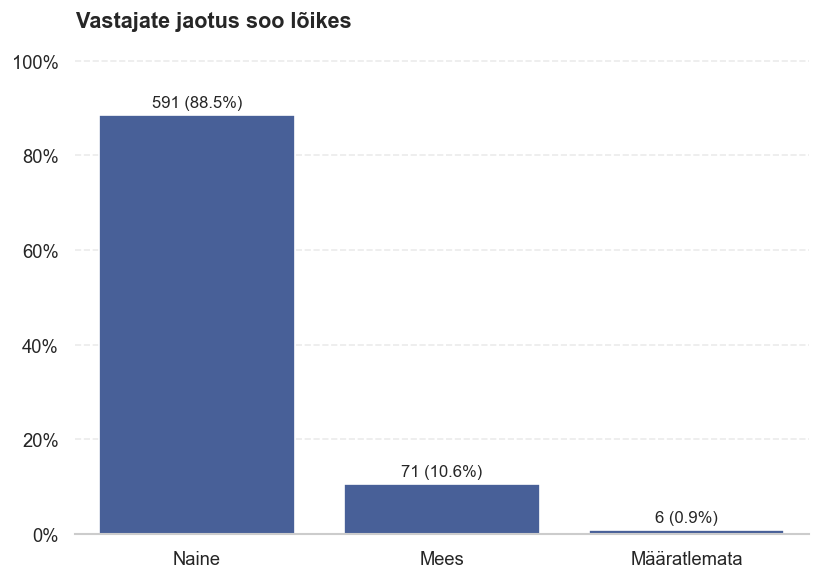

In [1212]:
# Leia vastajate arv soo alusel
sugu_sagedus = sagedustabel(data, koodid, 'K4_sugu')

# Soo jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    sugu_sagedus,
    "Vastajate jaotus soo lõikes",
    sort=True
)

plt.show()

In [824]:
# Leia, millise grupi vastajaid on kõige rohkem
print('Kõige sagedasem maakond (mood):')
print(mood(data, 'K5_elukoht'))

Kõige sagedasem maakond (mood):
   kood         vastus
0     1  Harju maakond


Vastuste jaotus:
 kood vastus_lyhike  vastuste_arv  protsent protsent_str
    1         Harju           406      60.8       60.8 %
   12         Tartu            88      13.2       13.2 %
    9         Pärnu            56       8.4        8.4 %
    4         Järva            35       5.2        5.2 %
   14      Viljandi            23       3.4        3.4 %
   10         Rapla            13       1.9        1.9 %
    7    Lääne-Viru            12       1.8        1.8 %
    5        Jõgeva             7       1.0        1.0 %
    8         Põlva             6       0.9        0.9 %
   11         Saare             5       0.7        0.7 %
   15          Võru             4       0.6        0.6 %
   16           Muu             4       0.6        0.6 %
    3      Ida-Viru             3       0.4        0.4 %
   13         Valga             3       0.4        0.4 %
    2          Hiiu             2       0.3        0.3 %
    6         Lääne             1       0.1        0.1 %


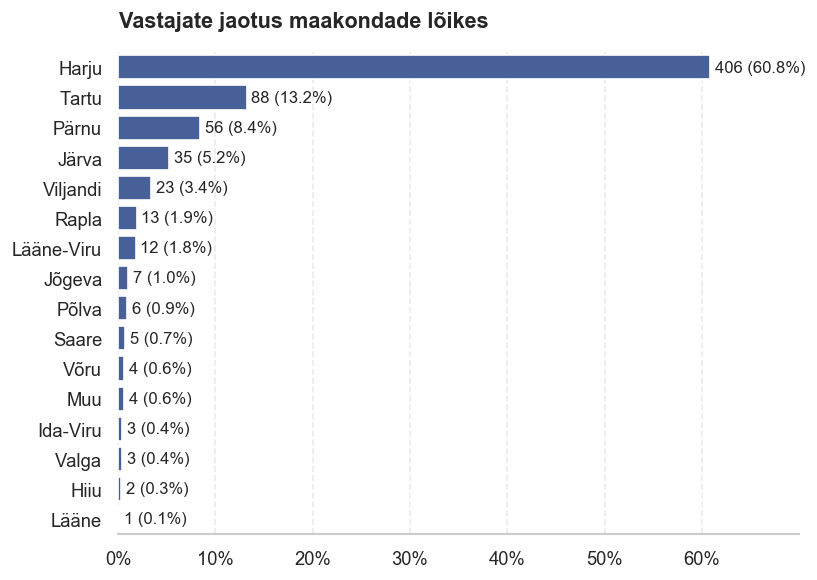

In [1213]:
# Leia vastajate arv elukoha alusel
elukoht_sagedus = sagedustabel(data, koodid, 'K5_elukoht')

# Elukoha jaotuse tulpdiagramm
fig, ax = loo_hor_tulpdiagramm(
    elukoht_sagedus,
    'Vastajate jaotus maakondade lõikes',
    sort=True
)

plt.show()

Vastanute jaotus
 kood vastus_lyhike  vastuste_arv  protsent protsent_str
    1         Eesti           641      96.0       96.0 %
    3          Vene            15       2.2        2.2 %
    2       Inglise             7       1.0        1.0 %
    4           Muu             5       0.7        0.7 %


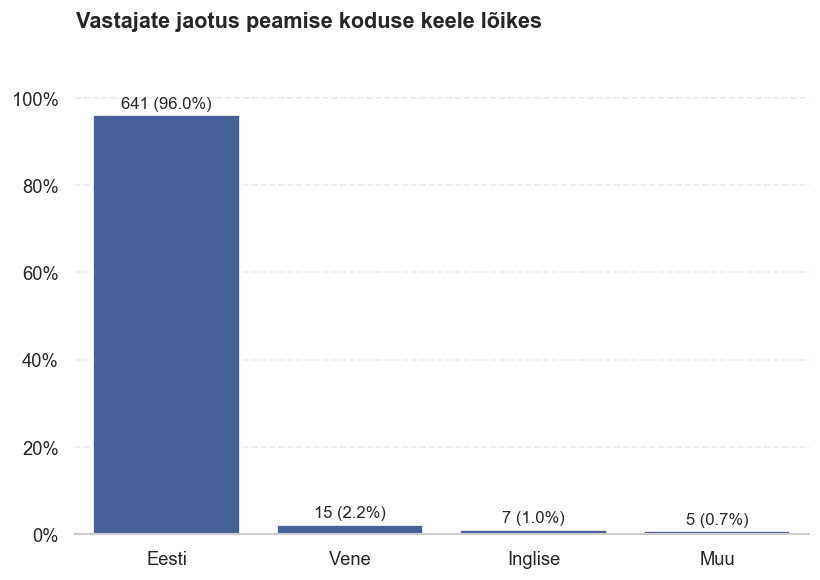

In [1214]:
# Leia vastajate arv keele alusel
keel_sagedus = sagedustabel(data, koodid, 'K6_keel')

# Keele jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    keel_sagedus,
    "Vastajate jaotus peamise koduse keele lõikes",
    sort=True
)

plt.show()

In [860]:
# Leia vastuse koodile vastav nimetus graafikul kuvamiseks
vanus_sildid = leia_sildi_mapping(koodid, 'K3_vanus')
sugu_sildid = leia_sildi_mapping(koodid, 'K4_sugu')
elukoht_sildid = leia_sildi_mapping(koodid, 'K5_elukoht')
keel_sildid = leia_sildi_mapping(koodid, 'K6_keel')
sorteerimiskaitumine_sildid = leia_sildi_mapping(koodid, 'K7_sorteerimiskaitumine')

## Demograafiliste näitajate vahelised seosed

In [1139]:
# Vanuseline jaotus elukoha alusel
vanus_elukoht = pd.crosstab(index=data['K5_elukoht'], columns=data['K3_vanus'])

vanus_elukoht.columns = vanus_sildid.values()
vanus_elukoht.index = elukoht_sildid.values()

vanus_elukoht

,<17,18-29,30-49,50-64,65+
Harju,22,81,236,56,11
Hiiu,0,0,2,0,0
Ida-Viru,0,1,1,1,0
Järva,26,5,2,2,0
Jõgeva,1,1,2,3,0
Lääne,0,0,0,1,0
Lääne-Viru,2,5,5,0,0
Põlva,0,0,4,1,1
Pärnu,0,8,36,12,0
Rapla,0,1,6,6,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
Lääne           1
Hiiu            2
Ida-Viru        3
Valga           3
Võru            4
Muu             4
Saare           5
Põlva           6
Jõgeva          7
Lääne-Viru     12
Rapla          13
Viljandi       23
Järva          35
Pärnu          56
Tartu          88
Harju         406
dtype: int64


(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'left': 'Vastajate vanuseline jaotus elukoha alusel'}>)

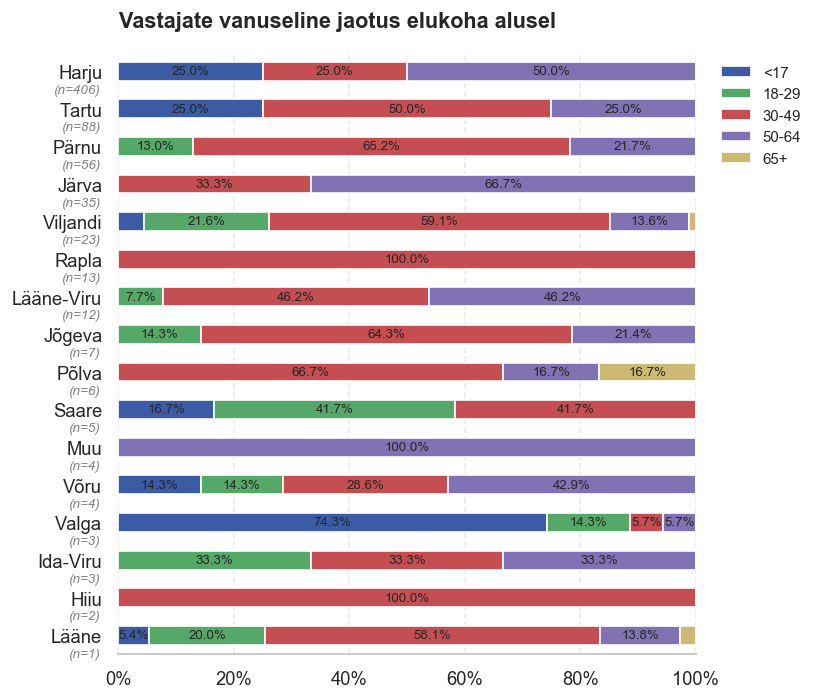

In [1172]:
# Vanuseline jaotus elukoha alusel
loo_hor_stacked_tulpdiagramm(vanus_elukoht, 'Vastajate vanuseline jaotus elukoha alusel')

In [1141]:
# Soo jaotus elukoha alusel
sugu_elukoht = pd.crosstab(index=data['K5_elukoht'], columns=data['K4_sugu'])

sugu_elukoht.columns = sugu_sildid.values()
sugu_elukoht.index = elukoht_sildid.values()

sugu_elukoht

,Mees,Naine,Määratlemata
Harju,40,363,3
Hiiu,0,2,0
Ida-Viru,0,3,0
Järva,17,17,1
Jõgeva,1,6,0
Lääne,0,1,0
Lääne-Viru,1,11,0
Põlva,1,5,0
Pärnu,8,48,0
Rapla,0,13,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
Lääne           1
Hiiu            2
Ida-Viru        3
Valga           3
Võru            4
Muu             4
Saare           5
Põlva           6
Jõgeva          7
Lääne-Viru     12
Rapla          13
Viljandi       23
Järva          35
Pärnu          56
Tartu          88
Harju         406
dtype: int64


(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'left': 'Vastajate sooline jaotus elukoha alusel'}>)

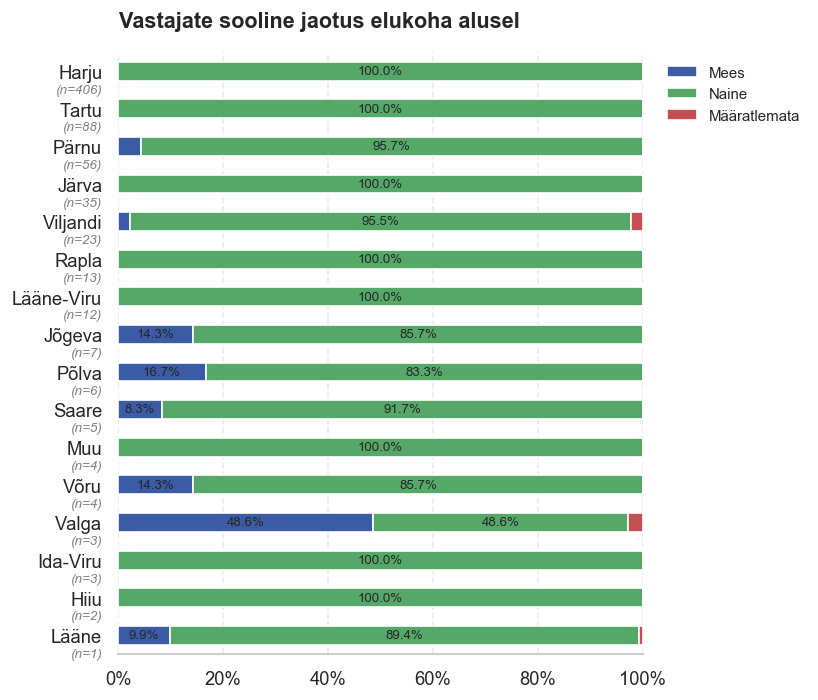

In [1142]:
# Sooline jaotus elukoha alusel
loo_hor_stacked_tulpdiagramm(sugu_elukoht, 'Vastajate sooline jaotus elukoha alusel')

In [1143]:
# Peamise koduse keele jaotus elukoha alusel
keel_elukoht = pd.crosstab(index=data['K5_elukoht'], columns=data['K6_keel'])

keel_elukoht.columns = keel_sildid.values()
keel_elukoht.index = elukoht_sildid.values()

keel_elukoht

,Eesti,Inglise,Vene,Muu
Harju,383,6,13,4
Hiiu,2,0,0,0
Ida-Viru,3,0,0,0
Järva,34,0,0,1
Jõgeva,7,0,0,0
Lääne,1,0,0,0
Lääne-Viru,12,0,0,0
Põlva,6,0,0,0
Pärnu,56,0,0,0
Rapla,13,0,0,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
Lääne           1
Hiiu            2
Ida-Viru        3
Valga           3
Võru            4
Muu             4
Saare           5
Põlva           6
Jõgeva          7
Lääne-Viru     12
Rapla          13
Viljandi       23
Järva          35
Pärnu          56
Tartu          88
Harju         406
dtype: int64


(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'left': 'Vastajate peamise koduse keele jaotus elukoha alusel'}>)

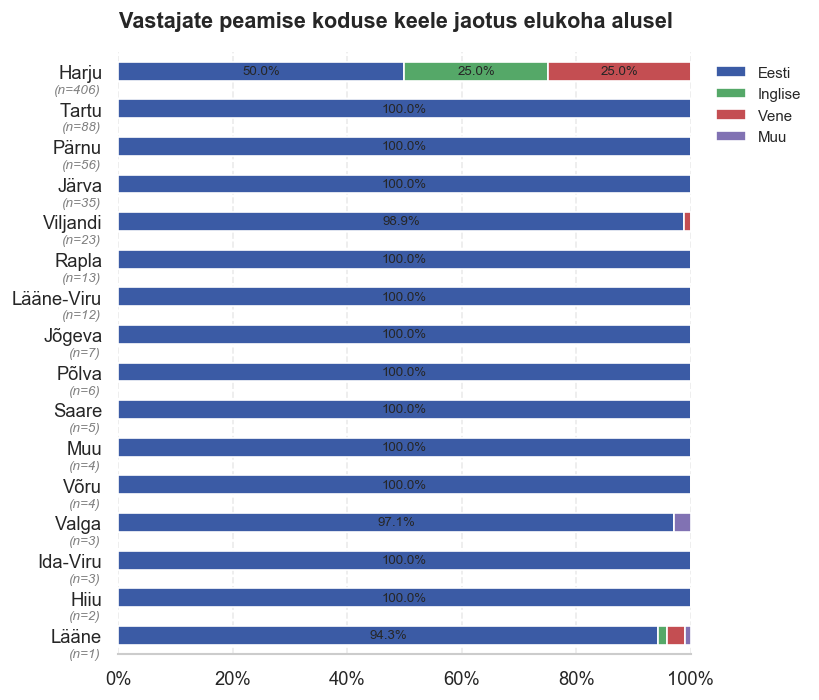

In [1144]:
# Peamise koduse keele jaotus elukoha alusel
loo_hor_stacked_tulpdiagramm(keel_elukoht, 'Vastajate peamise koduse keele jaotus elukoha alusel')

In [ ]:
# Vastajate sooline jaotus vanuse alusel risttabel
vanus_sugu = pd.crosstab(index=data['K3_vanus'], columns=data['K4_sugu'])

vanus_sugu.columns = sugu_sildid.values()
vanus_sugu.index = vanus_sildid.values()

vanus_sugu

,Mees,Naine,Määratlemata
<17,23,32,2
18-29,18,103,3
30-49,27,342,1
50-64,3,101,0
65+,0,13,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
<17       57
18-29    124
30-49    370
50-64    104
65+       13
dtype: int64


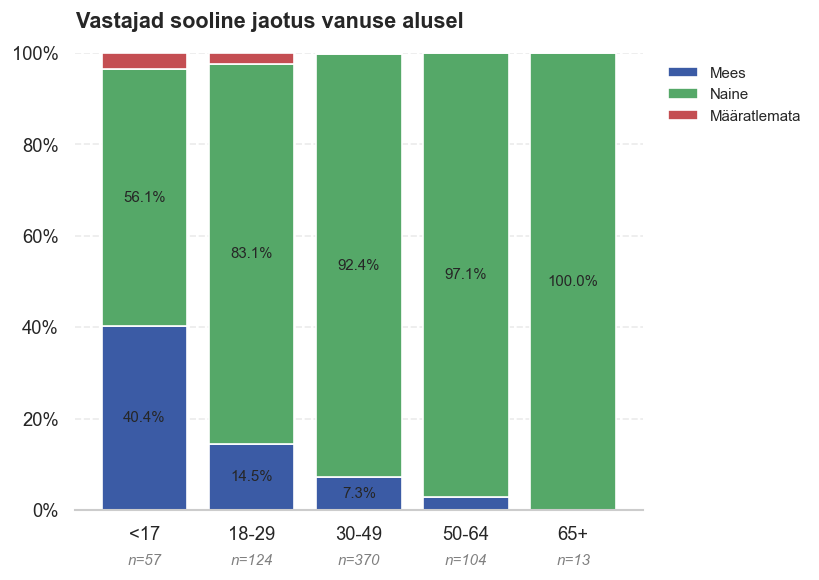

In [1147]:
# Vastajate sooline jaotus vanuse alusel risttabel
loo_stacked_tulpdiagramm(vanus_sugu, 'Vastajad sooline jaotus vanuse alusel')

plt.show()

In [1148]:
# Vastajate peamine kodune keel vanuse alusel risttabel
vanus_keel = pd.crosstab(index=data['K3_vanus'], columns=data['K6_keel'])

vanus_keel.columns = keel_sildid.values()
vanus_keel.index = vanus_sildid.values()

vanus_keel

,Eesti,Inglise,Vene,Muu
<17,51,0,3,3
18-29,116,2,5,1
30-49,359,4,6,1
50-64,103,1,0,0
65+,12,0,1,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
<17       57
18-29    124
30-49    370
50-64    104
65+       13
dtype: int64


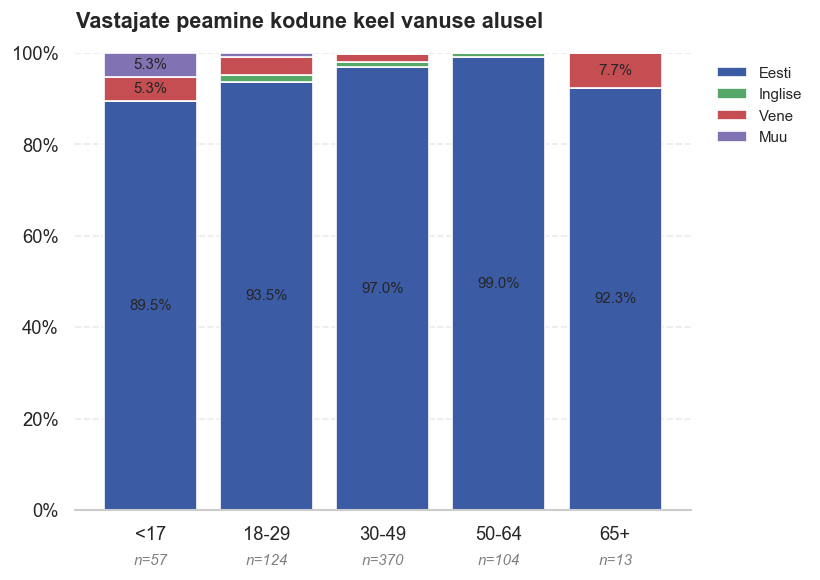

In [1149]:
loo_stacked_tulpdiagramm(vanus_keel, 'Vastajate peamine kodune keel vanuse alusel')

plt.show()

In [1151]:
# Peamine kodune keel soo alusel risttabel
sugu_keel = pd.crosstab(index=data['K4_sugu'], columns=data['K6_keel'])

sugu_keel.columns = keel_sildid.values()
sugu_keel.index = sugu_sildid.values()

sugu_keel

,Eesti,Inglise,Vene,Muu
Mees,67,1,1,2
Naine,568,6,14,3
Määratlemata,6,0,0,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
Mees             71
Naine           591
Määratlemata      6
dtype: int64


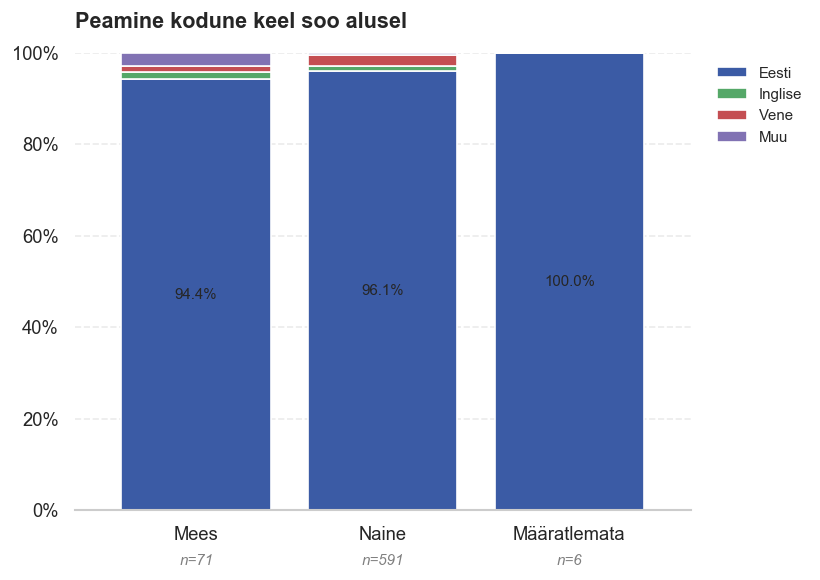

In [1152]:
loo_stacked_tulpdiagramm(sugu_keel, 'Peamine kodune keel soo alusel')

plt.show()

## Tarbijakäitumine

Kui palju sorteeritakse?

mitte-sorteerijaid 4,5%

3+ kategoorias sorteerib 83,6%

In [ ]:
sorteerimiskaitumine = sagedustabel(data, koodid, 'K7_sorteerimiskaitumine')
print('Vastanute jaotus sorteerimiskäitumise alusel:')
print(sorteerimiskaitumine.to_string(index=False))

Vastanute jaotus sorteerimiskäitumise alusel:
 kood      vastus_lyhike  vastuste_arv  protsent protsent_str
    1        Ei sorteeri            30       4.5        4.5 %
    2 Kuni 2 kategooriat            73      10.9       10.9 %
    3    3-5 kategooriat           424      63.5       63.5 %
    4     6+ kategooriat           134      20.1       20.1 %
    5  Null-kulu eluviis             1       0.1        0.1 %
    6                Muu             6       0.9        0.9 %
Vastanutest ei sorteeri üheski kategoorias: 4.5 %


In [ ]:
mitte_sorteerijad = data.
print(f'Vastanutest ei sorteeri üheski kategoorias: {sorteerimiskaitumine.loc[sorteerimiskaitumine['vastus_lyhike']=='Ei sorteeri', 'protsent_str'].to_string(index=False)}')

Vastanutest ei sorteeri üheski kategoorias: 4.5 %


In [1228]:
sorteerimine = data[['K7_sorteerimiskaitumine']].replace([3, 4, 5], 3)

In [1231]:
sorteerimiskaitumine2 = sagedustabel(sorteerimine, koodid, 'K7_sorteerimiskaitumine', use_full_codebook=False)
sorteerimiskaitumine2

,kood,vastus_lyhike,vastuste_arv,protsent,protsent_str
0,3,3-5 kategooriat,559,83.7,83.7 %
1,2,Kuni 2 kategooriat,73,10.9,10.9 %
2,1,Ei sorteeri,30,4.5,4.5 %
3,6,Muu,6,0.9,0.9 %


In [900]:
# Sorteerimiskäitumine vanuse alusel
vanus_sorteerimiskaitumine = pd.crosstab(index=data['K7_sorteerimiskaitumine'], columns=data['K3_vanus'])

vanus_sorteerimiskaitumine.index = sorteerimiskaitumine_sildid.values()
vanus_sorteerimiskaitumine.columns = vanus_sildid.values()

vanus_sorteerimiskaitumine

,<17,18-29,30-49,50-64,65+
Ei sorteeri,7,12,9,2,0
Kuni 2 kategooriat,15,22,29,5,2
3-5 kategooriat,30,76,235,73,10
6+ kategooriat,3,14,94,22,1
Null-kulu eluviis,0,0,0,1,0
Muu,2,0,3,1,0



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
<17       57
18-29    124
30-49    370
50-64    104
65+       13
dtype: int64


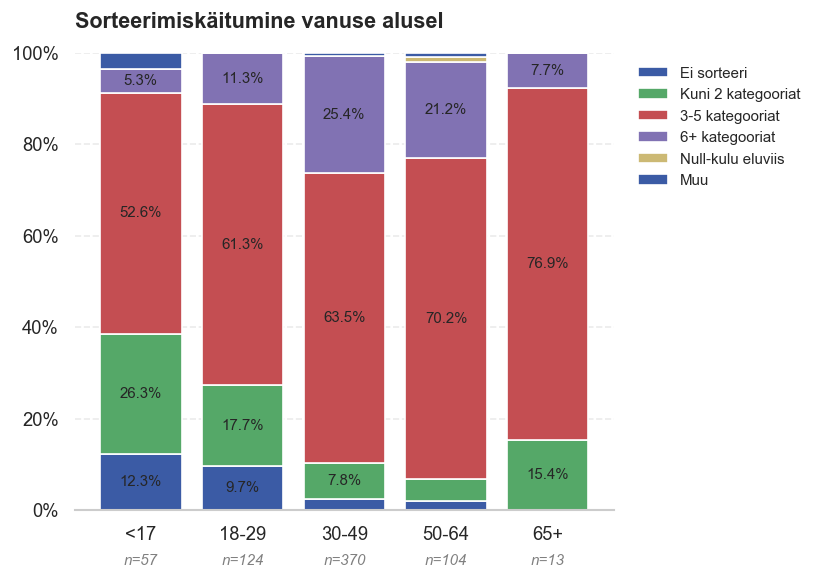

In [1175]:
# Sorteerimiskäitumine vanuse alusel
loo_stacked_tulpdiagramm(vanus_sorteerimiskaitumine.T, 'Sorteerimiskäitumine vanuse alusel')

plt.show()

In [1177]:
# Sorteerimiskäitumine elukoha alusel
elukoht_sorteerimiskaitumine = pd.crosstab(index=data['K5_elukoht'], columns=data['K7_sorteerimiskaitumine'])

elukoht_sorteerimiskaitumine.index = elukoht_sildid.values()
elukoht_sorteerimiskaitumine.columns = sorteerimiskaitumine_sildid.values()

elukoht_sorteerimiskaitumine

,Ei sorteeri,Kuni 2 kategooriat,3-5 kategooriat,6+ kategooriat,Null-kulu eluviis,Muu
Harju,16,50,258,80,0,2
Hiiu,0,0,2,0,0,0
Ida-Viru,0,0,3,0,0,0
Järva,2,7,22,2,0,2
Jõgeva,2,0,3,2,0,0
Lääne,0,0,0,1,0,0
Lääne-Viru,2,0,9,1,0,0
Põlva,0,0,4,2,0,0
Pärnu,1,5,36,14,0,0
Rapla,1,0,8,3,0,1



Vastuste arv: 668
Vastuste arv tunnuste kaupa:
Lääne           1
Hiiu            2
Ida-Viru        3
Valga           3
Võru            4
Muu             4
Saare           5
Põlva           6
Jõgeva          7
Lääne-Viru     12
Rapla          13
Viljandi       23
Järva          35
Pärnu          56
Tartu          88
Harju         406
dtype: int64


(<Figure size 840x720 with 1 Axes>,
 <Axes: title={'left': 'Sorteerimiskäitumine elukoha alusel'}>)

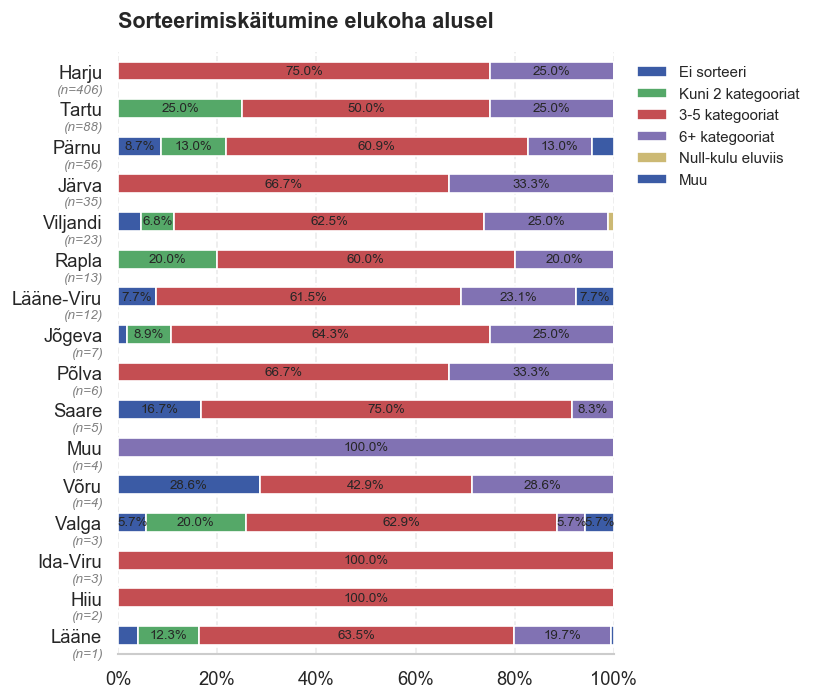

In [1181]:
loo_hor_stacked_tulpdiagramm(elukoht_sorteerimiskaitumine, 'Sorteerimiskäitumine elukoha alusel')

Kes on mitte-sorteerijad?

In [904]:
ei_sorteeri = data[data['K7_sorteerimiskaitumine'] == 1]
ei_sorteeri['K5_elukoht'] = ei_sorteeri['K5_elukoht'].map(elukoht_sildid)
ei_sorteeri['K3_vanus'] = ei_sorteeri['K3_vanus'].map(vanus_sildid)
df_sorteerimiskaitumine = pd.crosstab(index=ei_sorteeri['K5_elukoht'], columns=ei_sorteeri['K3_vanus'])

df_sorteerimiskaitumine

K3_vanus,18-29,30-49,50-64,<17
K5_elukoht,,,,
Harju,9,4,0,3
Järva,0,0,0,2
Jõgeva,0,0,2,0
Lääne-Viru,0,1,0,1
Pärnu,0,1,0,0
Rapla,0,1,0,0
Tartu,2,1,0,1
Viljandi,1,1,0,0


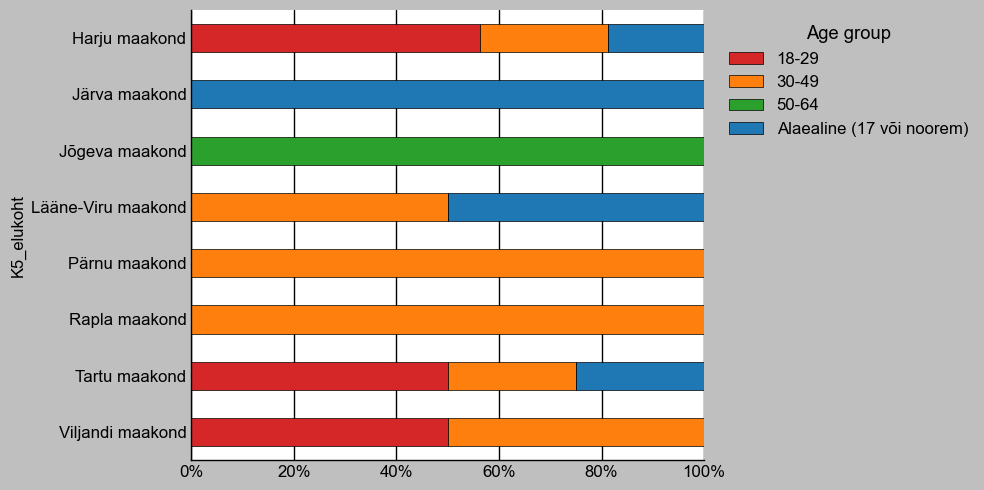

In [691]:
risttabel_tulpdiagrammiks(df_sorteerimiskaitumine)

Vastanute peamise koduse keele jaotus:
vastus_lyhike  vastuste_arv  protsent protsent_str
        Eesti           641      96.0       96.0 %
         Vene            15       2.2        2.2 %
      Inglise             7       1.0        1.0 %
          Muu             5       0.7        0.7 %


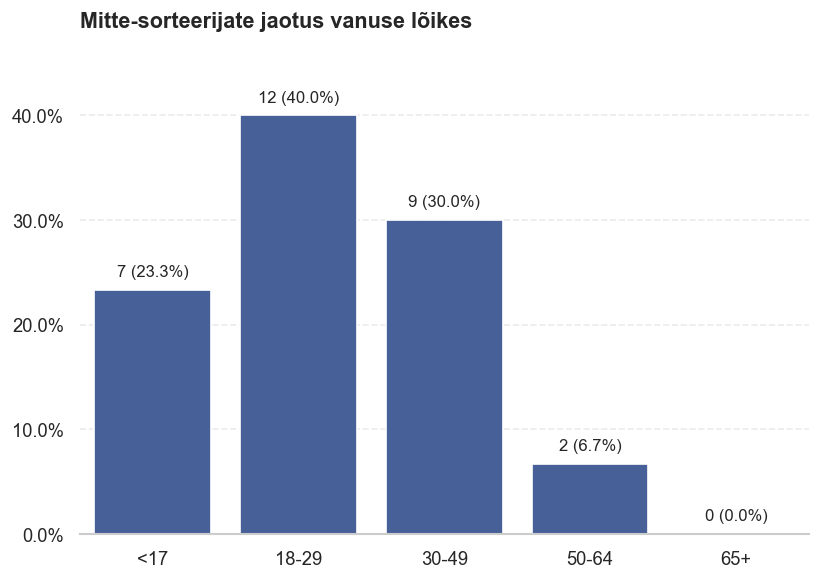

In [1050]:
# Leia vastajate arv keele alusel
ei_sorteeri= sagedustabel(data[data['K7_sorteerimiskaitumine'] == 1], koodid, 'K3_vanus')
print('Vastanute peamise koduse keele jaotus:')
print(keel_sagedus.to_string(index=False))

# Keele jaotuse tulpdiagramm
fig, ax = loo_tulpdiagramm(
    ei_sorteeri,
    "Mitte-sorteerijate jaotus vanuse lõikes"
)

plt.show()

In [586]:
# grouped_data = data.groupby(['K3_vanus', 'K7_sorteerimiskaitumine']).size().reset_index(name='count')
# ax = sns.barplot(data=grouped_data, x='K3_vanus', y='count', hue='K7_sorteerimiskaitumine')

<Axes: >

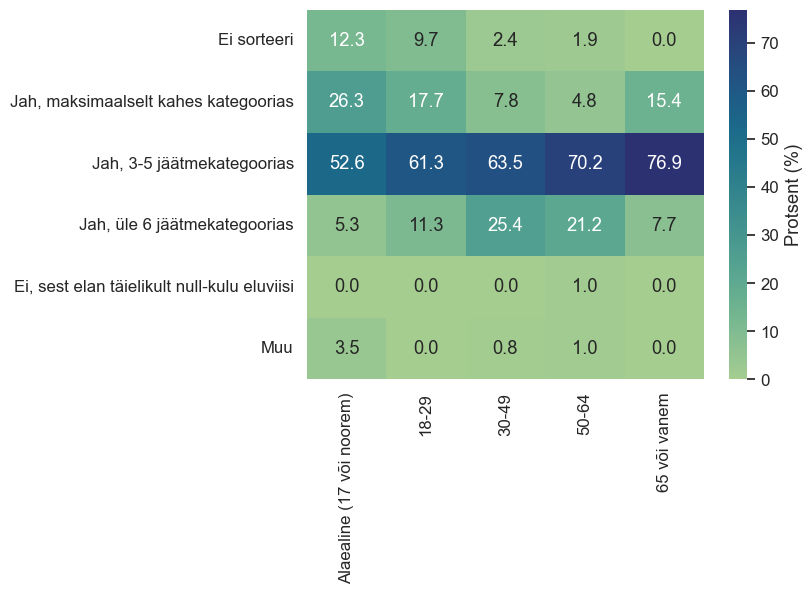

In [580]:
# ax = sns.heatmap(vanus_sorteerimiskaitumine, annot=True, linewidth=.5, cmap='crest')


df_pct = vanus_sorteerimiskaitumine.div(vanus_sorteerimiskaitumine.sum(axis=0), axis=1) * 100  # Calculate column percentages
sns.heatmap(df_pct, annot=True, fmt='.1f', cmap='crest', 
            cbar_kws={'label': 'Protsent (%)'})

Sorteerijad?

In [1233]:
sorteerimine = data[['K7_sorteerimiskaitumine']].replace([3, 4, 5], 3)

## Tarbijate teadmised ja teadlikkus

## Descriptive Statistics for This Survey Dataset

Based on the data dictionary analysis, this is a **textile waste and consumer behavior survey** with 105 variables. Here are the appropriate descriptive statistics by variable type:

### **1. Demographic Variables (Categorical - Nominal/Ordinal)**

**Variables:** K3_vanus (age), K4_sugu (gender), K5_elukoht (location), K6_keel (language)

**Recommended statistics:**
- **Frequency distributions** - count and percentage for each category
- **Mode** - most common category
- **Cross-tabulations** - relationships between demographics
- **Bar charts/pie charts** for visualization

**Reasoning:** Nominal variables lack numerical meaning, so only frequency-based measures apply.

---

### **2. Likert Scale Variables (Ordinal - 1-5 scales)**

**Variables:** K8_teadmiste_hinnang, K9_probleemi_tosidus, K17_valmisolek_parandamiseks, K21_loobumise_lihtsus, K37_rahulolu_garderoobiga, K41_ultrakiirmoe_ostmine, K43_roivaste_tellimine_proovimiseks (7 total)

**Recommended statistics:**
- **Median** - central tendency (more appropriate than mean for ordinal data)
- **Mode** - most frequent response
- **Interquartile range (IQR)** - spread of middle 50%
- **Frequency distribution** - % at each scale point
- **Mean** (with caveat) - acceptable if treating as interval data
- **Standard deviation** (with caveat) - if treating as interval
- **Stacked bar charts** or **diverging stacked bar charts** for visualization

**Reasoning:** Likert scales are technically ordinal, but often analyzed as interval data. Median is statistically safer, but mean is commonly used for practical interpretation.

---

### **3. Multiple Choice Questions (Binary/Boolean)**

**Variable groups:** 
- K15_mittevajalikud_tekstiilid (7 options)
- K19_loobumise_pohjused (9 options) 
- K22_peamised_valjakutsed (7 options)
- K23_kasutuskolbmatud_tekstiilid (7 options)
- K25_loobumisel_oluline (7 options)
- K32_teabe_allikad (10 options)
- K33_julgustavad_tegurid (7 options)

**Recommended statistics:**
- **Selection frequency** - % who selected each option
- **Response rate** - % who answered the question
- **Total selections per respondent** (mean, median) - shows if people select 1 vs many
- **Co-occurrence matrix** - which options are selected together
- **Ranked order** by frequency

**Reasoning:** Each option is independent; statistics should show popularity and patterns of selection.

---

### **4. Single-Choice Categorical Variables (Nominal)**

**Variables:** K7_sorteerimiskaitumine, K26_korduskasutuseks_sobimatud_tekstiilid, K28_riikliku_juhise_selgus, K29_sobiv_kogumisviis, K30_valmisolek_kategoriseerimiseks, K38_kandmise_kestus, K40_ostmissagedus

**Recommended statistics:**
- **Frequency table** - count and percentage
- **Mode** - most common choice
- **Diversity index** (optional) - how evenly distributed responses are
- **Chi-square tests** for associations with demographics

**Reasoning:** These are mutually exclusive categories without inherent order.

---

### **Summary Statistics Report Structure**

A complete analysis should include:

1. **Sample characteristics** (n, completion rate, demographics)
2. **Central tendency measures** (mean/median by variable type)
3. **Dispersion measures** (SD, IQR, range)
4. **Distribution analysis** (frequency tables, histograms)
5. **Bivariate analysis** (correlations, cross-tabs by demographics)
6. **Missing data analysis** (% missing by variable)
7. **Reliability checks** (for multi-item scales, calculate Cronbach's alpha if applicable)

This structure respects the measurement level of each variable type while providing actionable insights for textile waste management policy decisions.

In [763]:
def plot_stacked(df, title, normalize=True, save=None):
    
    if normalize:
        df_plot = df.div(df.sum(axis=1), axis=0)
    else:
        df_plot = df.copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    df_plot.plot(
        kind="bar",
        stacked=True,
        color=PALETTE,
        ax=ax,
        width=0.8
    )

    ax.set_title(title, loc="left")
    ax.set(xlabel=None, ylabel=None)

    if normalize:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylim(0, 1)

    ax.tick_params(axis="x", rotation=45)

    ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight")

    return fig, ax

(<Figure size 960x600 with 1 Axes>, <Axes: title={'left': 'Vanus ja elukoht'}>)

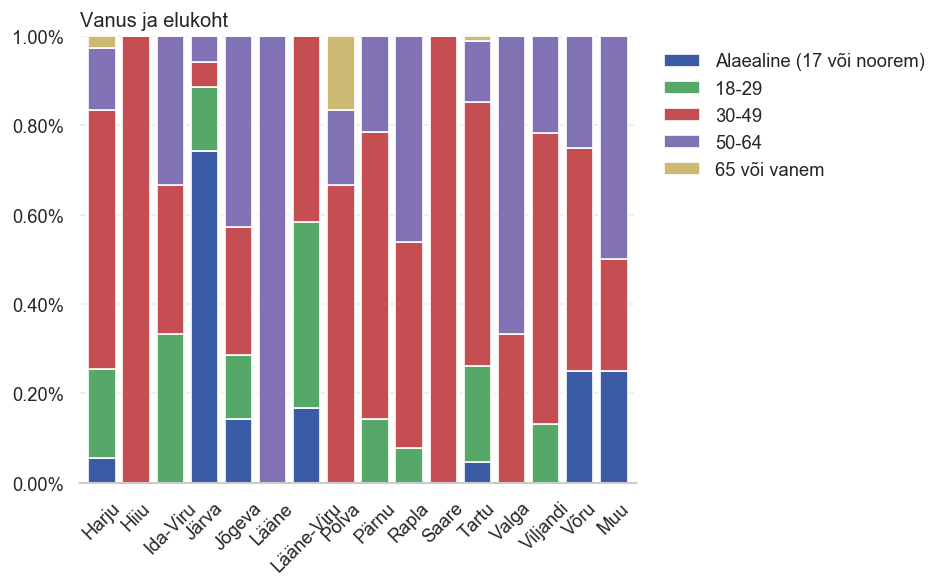

In [764]:
plot_stacked(vanus_elukoht, "Vanus ja elukoht")